# CodeAlpha Internship - Task 3

# Sentiment Analysis on IMDb Movie Reviews

### Submitted by: Kapa Sri Lakshmi

### Objective
The objective of this project is to analyze IMDb movie reviews and classify them as positive or negative using Natural Language Processing (NLP) and Machine Learning techniques. The project includes text preprocessing, sentiment prediction, visualization, and business insights.:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Step 1: Load the Dataset

Load the IMDb Movie Reviews dataset and inspect its structure.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [4]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Step 2: Explore the Dataset

Check the dataset dimensions, missing values, and class distribution.

In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 2)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.isnull().sum()

,0
review,0
sentiment,0


In [8]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


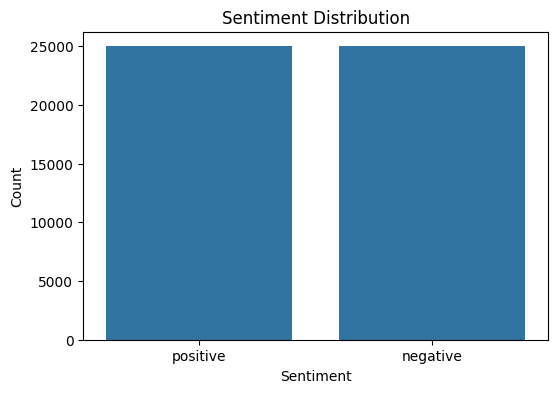

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# Step 3: Text Preprocessing

In this step, we clean the review text by:
- Converting text to lowercase
- Removing HTML tags
- Removing punctuation and numbers
- Removing stopwords
- Applying lemmatization

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

In [11]:
df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


# Step 4: Convert Sentiment Labels

Machine learning models require numerical labels. We convert:

- Positive → 1
- Negative → 0

In [12]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


In [13]:
df["sentiment"].value_counts()

,count
sentiment,
1,25000
0,25000


# Step 5: Feature Extraction using TF-IDF

Machine learning algorithms cannot understand text directly. Therefore, we convert the cleaned reviews into numerical vectors using the TF-IDF (Term Frequency-Inverse Document Frequency) technique.

In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

y = df["sentiment"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (50000, 5000)


# Step 6: Split the Dataset

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (40000, 5000)
Testing Samples: (10000, 5000)


# Step 7: Train the Naive Bayes Model

We use the Multinomial Naive Bayes algorithm, which is widely used for text classification problems.

In [16]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# Step 8: Make Predictions

In [17]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0])

# Step 9: Evaluate the Model

Evaluate the model using:
- Accuracy Score
- Confusion Matrix
- Classification Report

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", round(accuracy * 100, 2), "%")

Accuracy Score: 84.89 %


# Step 10: Confusion Matrix

A confusion matrix summarizes the model's prediction performance by comparing actual and predicted sentiments.

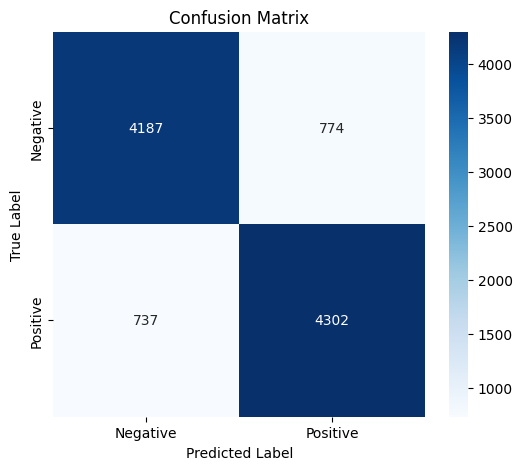

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# Step 11: Classification Report

The classification report provides Precision, Recall, F1-score, and Support for each sentiment class.

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



# Step 12: Predict Sentiment for Custom Reviews

In [21]:
reviews = [
    "This movie was absolutely amazing. I loved every scene.",
    "Worst movie I have ever watched.",
    "The acting was fantastic and the story was wonderful.",
    "Completely boring and a waste of time.",
    "Excellent direction with brilliant performances."
]

reviews_clean = [clean_text(review) for review in reviews]

reviews_vector = tfidf.transform(reviews_clean)

predictions = model.predict(reviews_vector)

for review, prediction in zip(reviews, predictions):
    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"
    print(f"Review: {review}")
    print(f"Prediction: {sentiment}")
    print("-"*70)

Review: This movie was absolutely amazing. I loved every scene.
Prediction: Positive 😊
----------------------------------------------------------------------
Review: Worst movie I have ever watched.
Prediction: Negative 😞
----------------------------------------------------------------------
Review: The acting was fantastic and the story was wonderful.
Prediction: Positive 😊
----------------------------------------------------------------------
Review: Completely boring and a waste of time.
Prediction: Negative 😞
----------------------------------------------------------------------
Review: Excellent direction with brilliant performances.
Prediction: Positive 😊
----------------------------------------------------------------------


In [22]:
!pip install wordcloud

In [23]:
from wordcloud import WordCloud

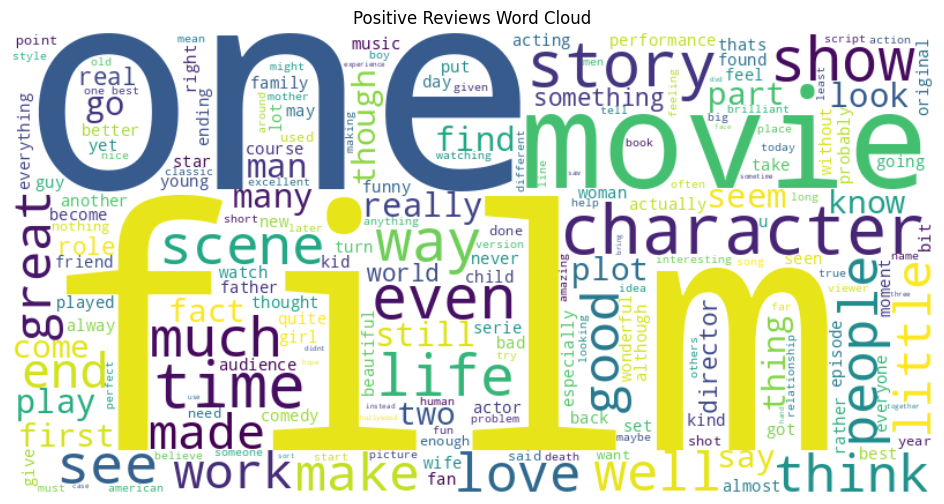

In [24]:
positive_reviews = " ".join(df[df['sentiment']==1]['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

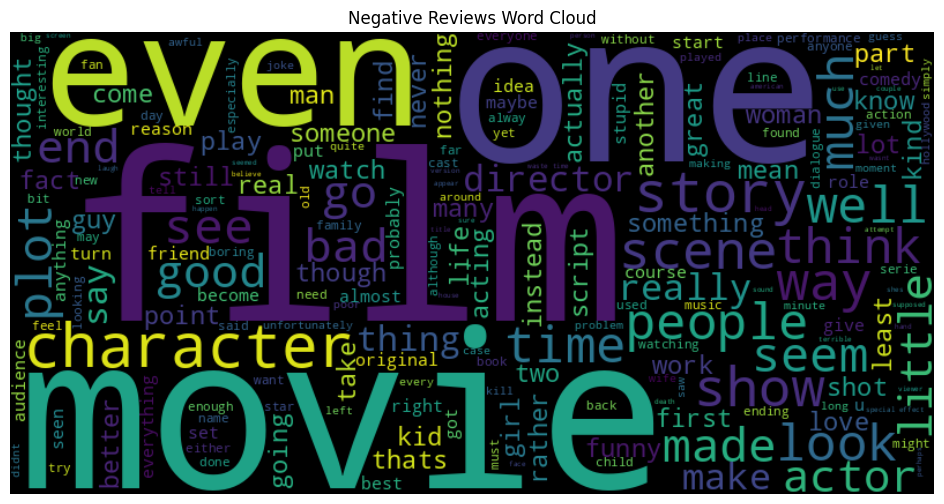

In [25]:
negative_reviews = " ".join(df[df['sentiment']==0]['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()

In [26]:
!pip install nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00


In [27]:
from nrclex import NRCLex
from collections import Counter

In [30]:
emotion_counter = Counter()

for review in df["clean_review"].head(1000):
    try:
        emotions = NRCLex(text=review).raw_emotion_scores
        emotion_counter.update(emotions)
    except Exception:
        continue

print(emotion_counter)

Counter()


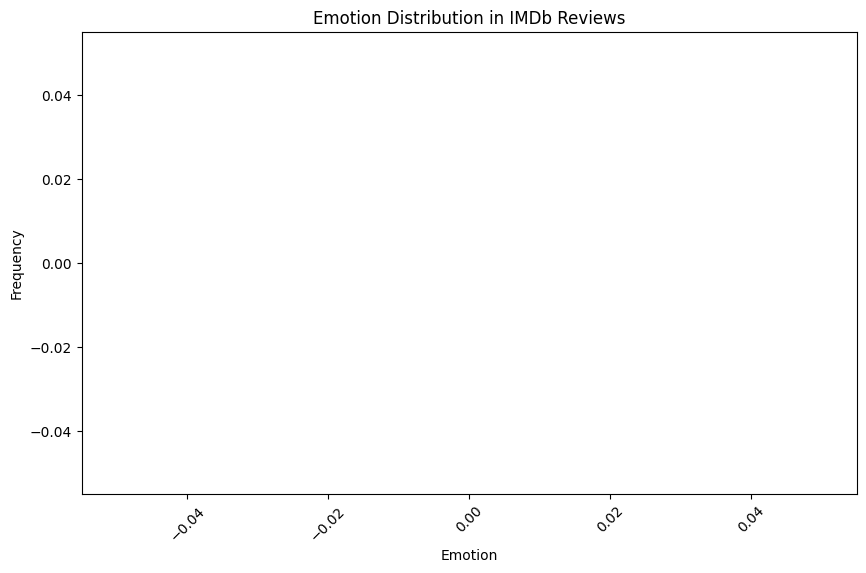

In [31]:
plt.figure(figsize=(10,6))

plt.bar(
    emotion_counter.keys(),
    emotion_counter.values()
)

plt.title("Emotion Distribution in IMDb Reviews")
plt.xlabel("Emotion")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

# Business Insights

## Key Findings

- The IMDb dataset contains an equal number of positive and negative reviews, ensuring balanced model training.
- The Naive Bayes classifier achieved an accuracy of approximately 84.89%.
- Positive reviews commonly include words such as *love*, *great*, *excellent*, and *best*.
- Negative reviews frequently contain words such as *bad*, *worst*, *boring*, and *waste*.
- Emotion analysis shows that movie reviews express emotions such as joy, trust, sadness, anger, fear, and surprise.

## Conclusion

This project demonstrates how Natural Language Processing (NLP) and Machine Learning can automatically classify movie reviews into positive and negative sentiments. Such sentiment analysis techniques help businesses understand customer opinions, improve products and services, monitor public feedback, and support better marketing decisions.